In [1]:
import json

import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from utils import ROOT_PATH
from dataset import BurnoutDataset
from model_factory import Model
from train_model import train_model
from torch.optim import Adam
from dataset import ModelHistory
from functools import partial
from sklearn.model_selection import ParameterGrid

In [2]:
f1_score_metric = partial(f1_score, average="weighted")
recall_metric = partial(recall_score, average="weighted")
precision_metric = partial(precision_score, average="weighted", zero_division = 0)

In [4]:
train_dataset = BurnoutDataset("train")
test_dataset = BurnoutDataset("test")
val_dataset = BurnoutDataset("val")

In [5]:
model1 = Model([64, 128], [-1, -1], [False, False], [nn.ReLU, nn.ReLU], [False, False], 37, 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = model1.to(device)

model2 = Model([32, 64], [0.3, 0.3], [False, False], [nn.ReLU, nn.ReLU], [False, False], 37, 6)
model2 = model2.to(device)

In [6]:
model1, history1 = train_model(model1, 16, 10, 1e-3, 1e-6, Adam, nn.CrossEntropyLoss, device, {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric,
})

model2, history2 = train_model(model2, 16, 10, 1e-3, 1e-6, Adam, nn.CrossEntropyLoss, device, {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

100%|██████████| 1500/1500 [00:00<00:00, 3098.55it/s]


In [3]:
def plot_history(step_name: str, model_history: ModelHistory, max_img_per_width = 3):
    import math
    try:
        metrics_used = model_history.history[step_name]
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        curr_ax.plot(metrics_used[metric])
        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()




In [4]:
def _plot_step_for_models(names: list[str], data, ax: plt.Axes):
    import seaborn as sns
    for name, data in zip(names, data):
        sns.lineplot(x=range(len(data)), y=data, ax=ax, label=name)


def plot_histories(step_name: str, histories: list[ModelHistory], max_img_per_width = 3):
    import math
    try:
        metrics_used = histories[0].history[step_name]
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    models_names = [history.name for history in histories]

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        _plot_step_for_models(models_names, [history.history[step_name][metric] for history in histories], curr_ax)

        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()

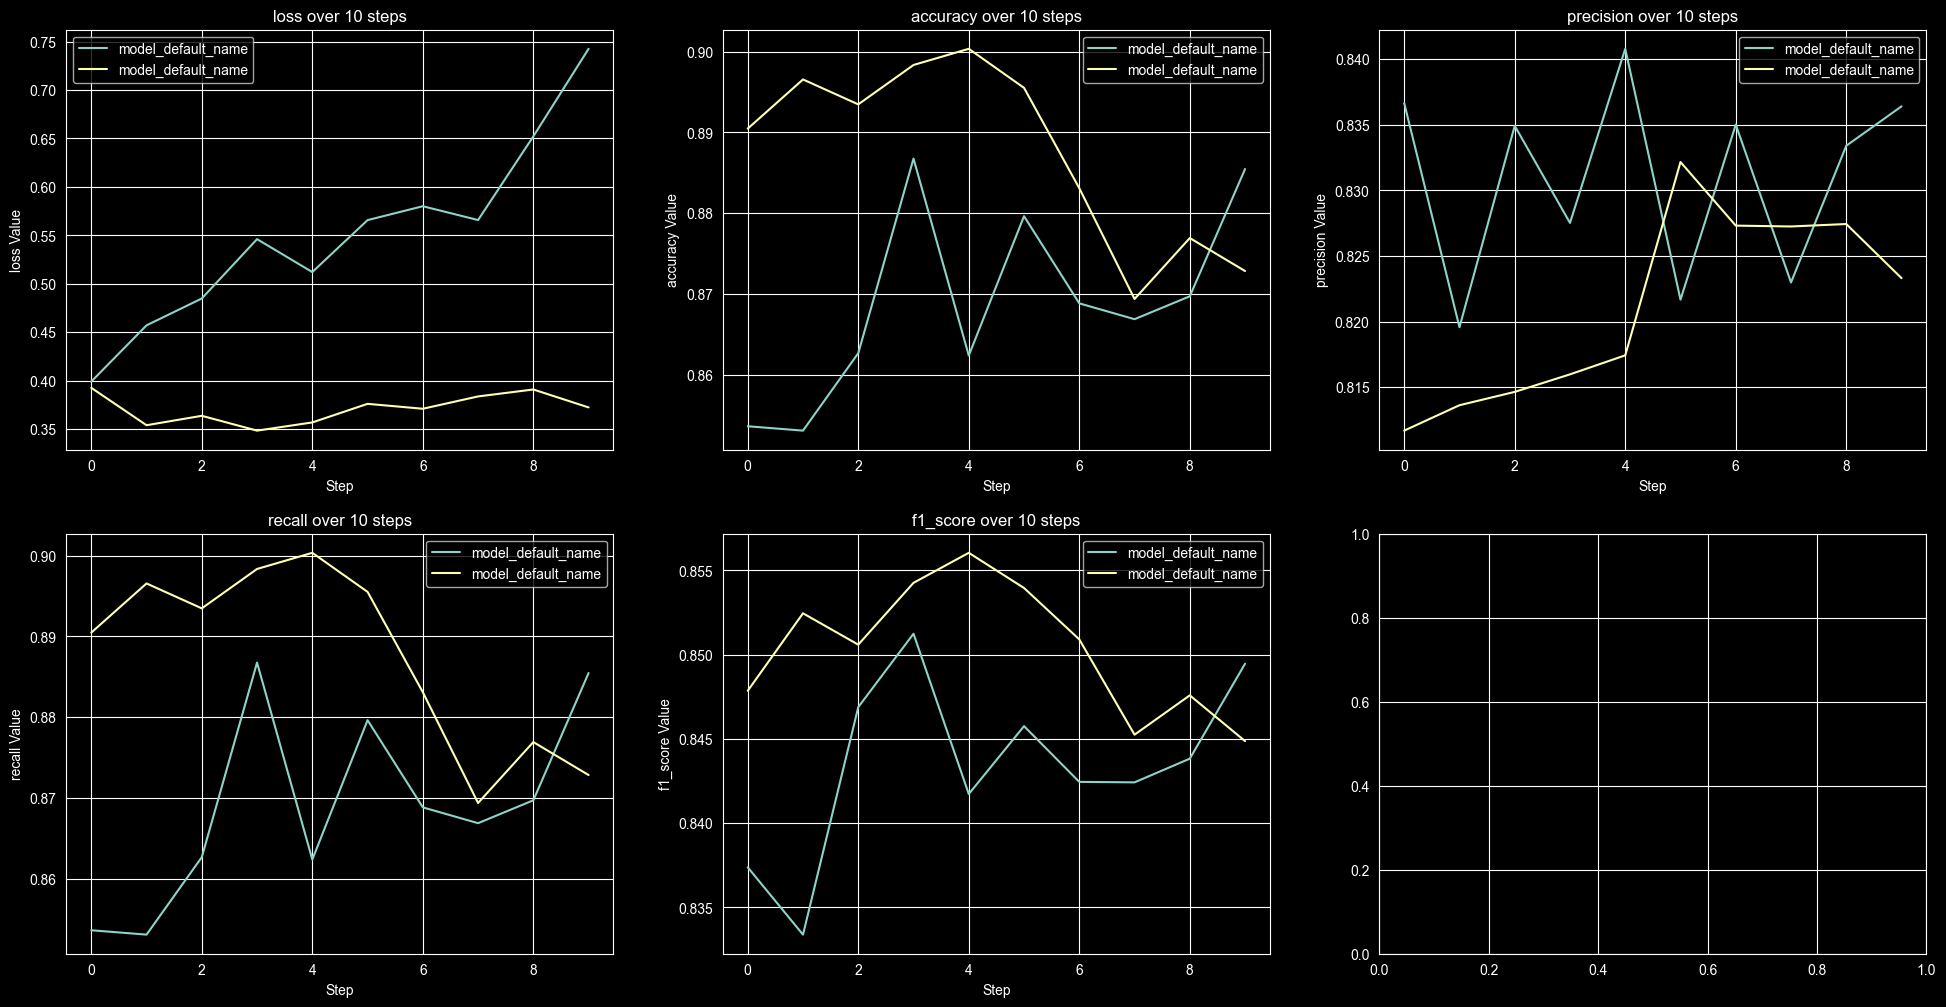

In [11]:
plot_histories("val", [history1, history2])

In [15]:
import random

def _find_worst_model(models: dict):
    worst_model_name = None
    worst_model_score = -float('inf')

    for k, v in models.items():
        curr_model_loss = v[1].history['val']['loss'][-1]
        if curr_model_loss > worst_model_score:
            worst_model_score = curr_model_loss
            worst_model_name = k

    return worst_model_name, models[worst_model_name]

def train_many_models(n_models, layers_num, neurons_num, activations, dropouts, learning_rates, weight_decays, optimizers, is_skipping_conn, is_batch_norm, epochs, batch_sizes, top_models,
                      metrics=None):
    if metrics is None:
        metrics = dict()

    models = dict()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def _ensure_list(val):
        return val if isinstance(val, list) else [val]

    layers_list = _ensure_list(layers_num)
    neurons_list = _ensure_list(neurons_num)
    activations_list = _ensure_list(activations)
    dropouts_list = _ensure_list(dropouts)
    lr_list = _ensure_list(learning_rates)
    wd_list = _ensure_list(weight_decays)
    opt_list = _ensure_list(optimizers)
    skip_list = _ensure_list(is_skipping_conn)
    bn_list = _ensure_list(is_batch_norm)
    batch_list = _ensure_list(batch_sizes)

    for model_iter in range(n_models):
        curr_layers = random.choice(layers_list)
        curr_neurons = random.choice(neurons_list)
        curr_lr = random.choice(lr_list)
        curr_wd = random.choice(wd_list)
        curr_opt = random.choice(opt_list)
        curr_batch = random.choice(batch_list)

        curr_dropouts = [random.choice(dropouts_list) for _ in range(curr_layers + 1)]
        curr_activations = [random.choice(activations_list) for _ in range(curr_layers + 1)]
        curr_skips = [random.choice(skip_list) for _ in range(curr_layers + 1)]
        curr_bns = [random.choice(bn_list) for _ in range(curr_layers + 1)]

        model = Model(
            neurons=curr_neurons,
            dropouts=curr_dropouts,
            is_batchnorm=curr_bns,
            activations=curr_activations,
            is_skipping_conn=curr_skips,
            input_shape=37,
            output_shape=6,
            name=f"model_{model_iter}"
        ).to(device)

        model, history = train_model(
            model,
            batch_size=curr_batch,
            epochs=epochs,
            learning_rate=curr_lr,
            lr_decay=curr_wd,
            optimizer=curr_opt,
            criterion=nn.CrossEntropyLoss,
            device=device,
            metrics=metrics
        )

        model_val_loss = history.history['val']['loss'][-1]

        if len(models) < top_models:
            models[model.name] = (model, history)
        else:
            worst_name, worst_model_data = _find_worst_model(models)
            worst_loss = worst_model_data[1].history['val']['loss'][-1]

            if model_val_loss < worst_loss:
                models.pop(worst_name)
                models[model.name] = (model, history)

    return models

In [12]:
def save_best_models_info(models: dict[str, tuple[Model, ModelHistory]]):
    infos_to_dump = []

    for model, history in models.values():
        infos_to_dump.append(model.model_info)

    with open("best_models_info.json", 'w') as f:
        json.dump(infos_to_dump, f, indent=4)




In [13]:
def gather_histories(models: dict[str, tuple[Model, ModelHistory]]):
    histories = []
    for values in models.values():
        histories.append(values[1])
    return histories



100%|██████████| 375/375 [00:00<00:00, 763.75it/s]


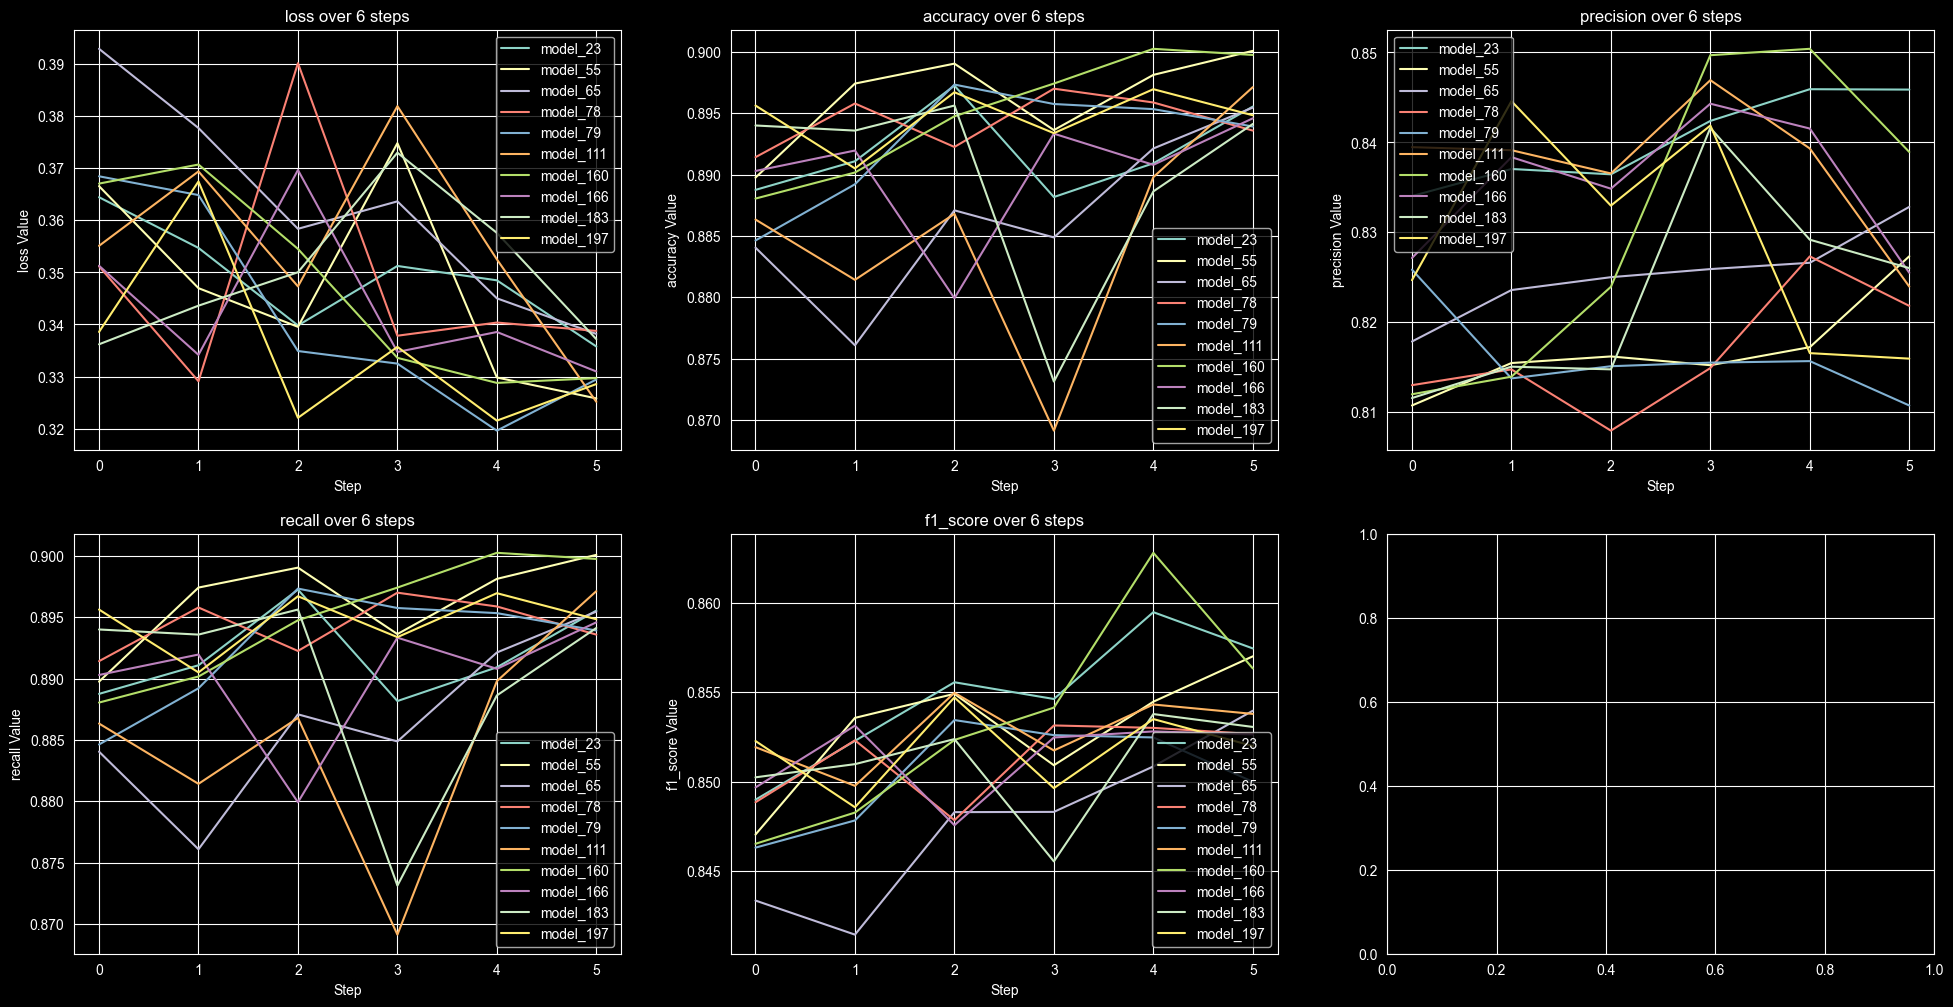

In [18]:
best_models = train_many_models(200, [0, 1, 2], [32, 64, 128], [nn.ReLU, nn.SELU, nn.Tanh, nn.GELU], [-1, 0.2, 0.4], [1e-4, 1e-3, 1e-2], [1e-5, 1e-4], [torch.optim.RMSprop, torch.optim.Adam], is_skipping_conn=[True, False], is_batch_norm=[False, True], epochs=6, batch_sizes=[32, 64], top_models=10, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

plot_histories("val", gather_histories(best_models))

save_best_models_info(best_models)


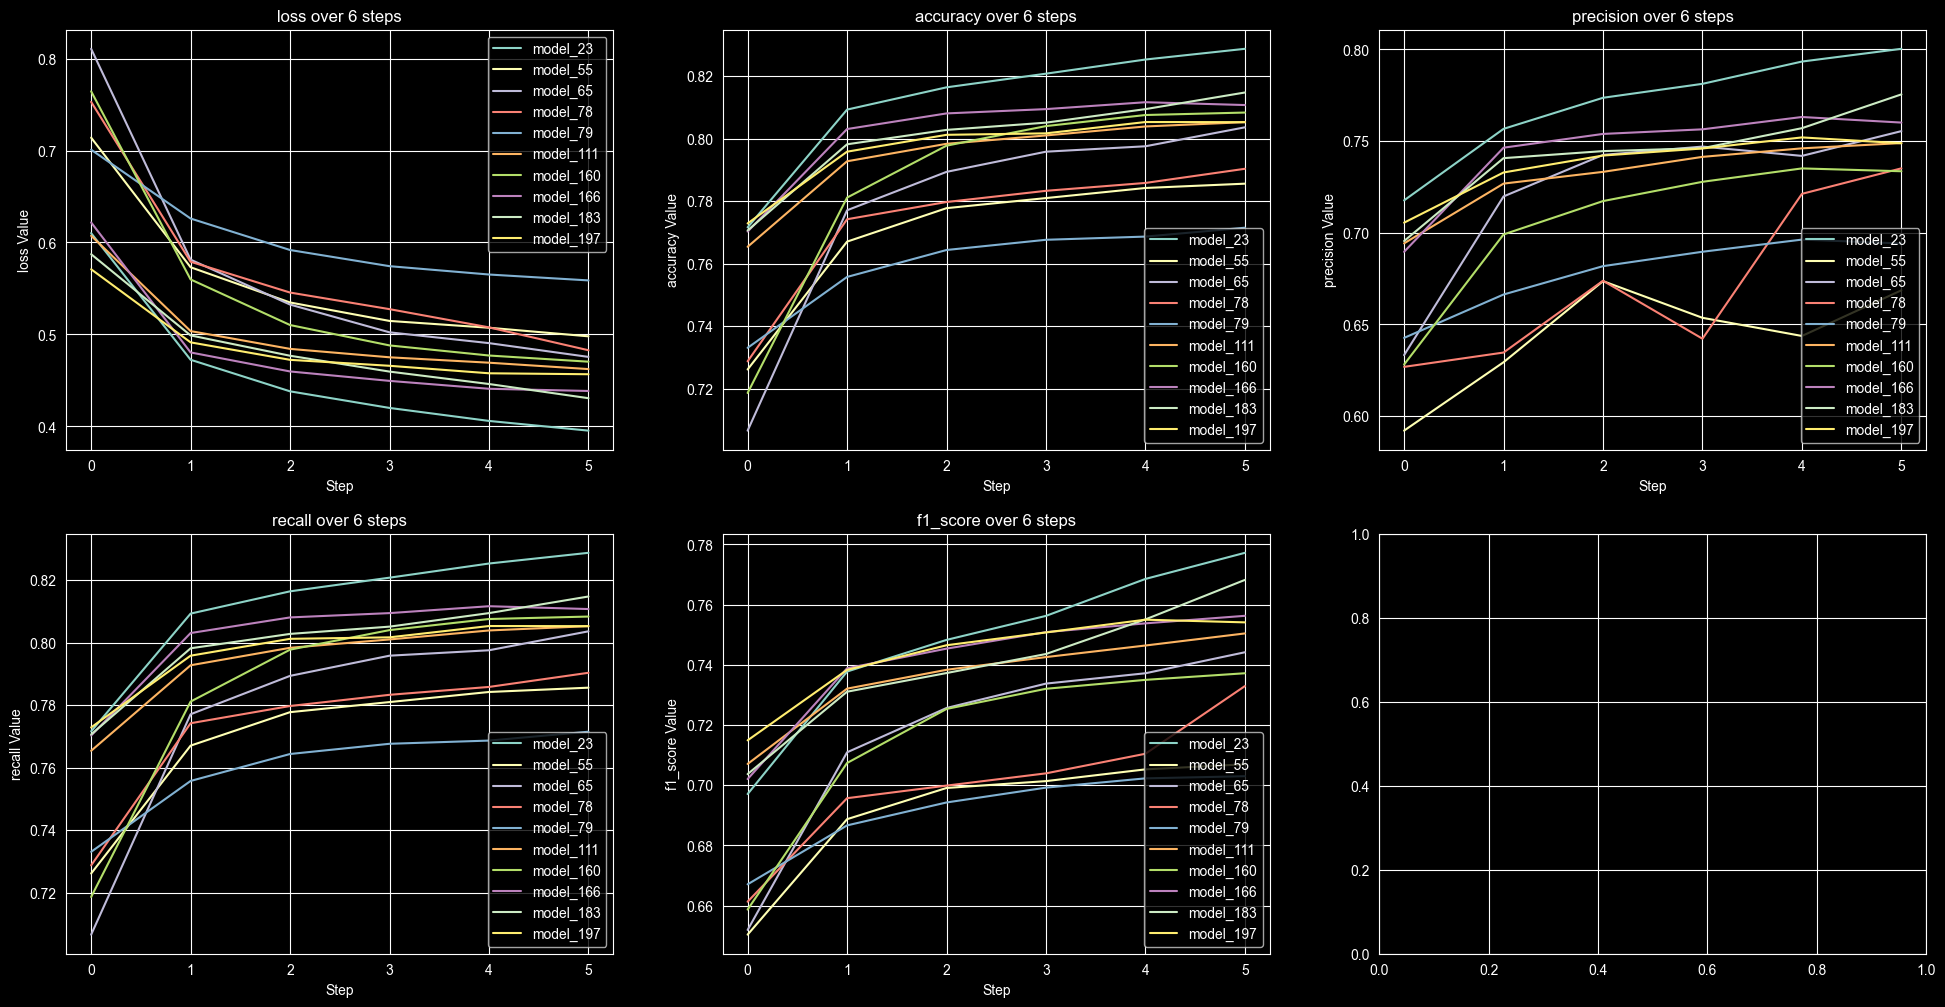

In [19]:
plot_histories("train", gather_histories(best_models))
